In [2]:
#importing required python classes and packages
import os
import pickle
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import mahotas

from tqdm.notebook import tqdm

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler

os.makedirs("model", exist_ok=True)

In [3]:
#defining function to extract features from videos
def fd_hu_moments(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    feature = cv2.HuMoments(cv2.moments(image)).flatten()
    return feature

# feature-descriptor-2: Haralick Texture
def fd_haralick(image):
    # convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # compute the haralick texture feature vector
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    # return the result
    return haralick

# feature-descriptor-3: Color Histogram
def fd_histogram(image, mask=None):
    bins = 8
    # convert the image to HSV color-space
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # compute the color histogram
    hist = cv2.calcHist([image], [0, 1, 2], None, [bins, bins, bins], [0, 256, 0, 256, 0, 256])
    # normalize the histogram
    cv2.normalize(hist, hist)
    # return the histogram
    return hist.flatten()

analyzer = SentimentIntensityAnalyzer()

In [4]:
#function to extract all frames from videos and then extract features from each frame
def video_to_frames(video_path):
    count = 0
    image_list = []
    cap = cv2.VideoCapture(video_path)
    while cap.isOpened():
        ret, frame = cap.read()
        if ret is False or count > 50:
            break
        img = cv2.resize(frame, (224, 224))
        fv_hu_moments = fd_hu_moments(img.copy())
        fv_haralick = fd_haralick(img.copy())
        fv_histogram = fd_histogram(img.copy())
        img = np.hstack([fv_histogram, fv_haralick, fv_hu_moments])
        image_list.append(img)
        count += 1
    cap.release()
    cv2.destroyAllWindows()
    return np.asarray(image_list).ravel()

In [6]:
#loading videos and caption dataset
dataset = pd.read_csv(r"C:\Users\rahul\INTERNSHIP\DATASETS\Captions.csv")
dataset

,VideoID,Start,End,WorkerID,Source,AnnotationTime,Language,Description
0,mv89psg6zh4,33,46,588702,unverified,55,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
1,mv89psg6zh4,33,46,588702,unverified,37,Slovene,Papagaj se umiva pod tekočo vodo v lijaku.
2,mv89psg6zh4,33,46,362812,unverified,11,Macedonian,папагал се бања
3,mv89psg6zh4,33,46,968828,unverified,84,German,Ein Wellensittich duscht unter einem Wasserhahn.
4,mv89psg6zh4,33,46,203142,unverified,14,Romanian,o pasare sta intr-o chiuveta.
...,...,...,...,...,...,...,...,...
122599,m7x8uIdg2XU,67,73,309959,unverified,19,English,The lady added a cream sauce to the pasta.
122600,m7x8uIdg2XU,67,73,130040,unverified,27,English,women are cooking her kichen
122601,m7x8uIdg2XU,67,73,762891,unverified,18,English,The woman is pouring cream over the pasta.
122602,m7x8uIdg2XU,67,73,733696,unverified,223,Tamil,ஒருவர் பாத்திரத்தில் பாலை ஊற்றிக்கொண்டு இருக்க...


In [7]:
#function to get caption for given video and then clean the caption by removing digits and special symbols
def getCaption(video_path):
    caption = ""
    for i in range(len(dataset)): #loop all videos from dataset
        path = dataset[i,0]+"_"+str(dataset[i,1])+"_"+str(dataset[i,2])+".avi"
        if video_path == path: #if dataset and given path matches for video then extract caption
            caption = dataset[i,7].strip()
            caption = caption.lower()
            caption = caption.replace(".","")
            caption = caption.replace('[^A-Za-z]', '')
            caption = caption.replace('\s+', ' ')
            caption = 'startseq ' + " ".join([word for word in caption.split() if len(word)>1]) + ' endseq'
            break
    return caption

In [8]:
#loop each video from dataset and then extract features and captions for training
if os.path.exists("model/images.npy"):
    images = np.load("model/images.npy")
    captions = np.load("model/captions.npy")
else:
    features = {}
    index = 0
    dataset = dataset.values
    for i in range(len(dataset)):
        video_path = dataset[i,0]+"_"+str(dataset[i,1])+"_"+str(dataset[i,2])+".avi"
        if video_path not in features.keys():
            frames = video_to_frames('YouTubeClips/'+video_path)
            if frames.shape[0] == 27132:
                features[video_path] = frames
                index += 1
            if len(features) > 300:
                break
    f = open('model/features.pckl', 'wb')
    pickle.dump(features, f)
    f.close()
    images = []
    captions = []
    for key, values in features.items():
        caption = getCaption(key)
        images.append(values)
        captions.append(caption)
    images = np.asarray(images)
    captions = np.asarray(captions)
    np.save("model/images", images)
    np.save("model/captions", captions)
    print("Video Features & Caption Extraction Completed")
    print("Total Number of Loaded Videos = "+str(images.shape[0]))
    print("Total Frames Processed = "+str(images.shape[0]*50))

Video Features & Caption Extraction Completed
Total Number of Loaded Videos = 301
Total Frames Processed = 15050


In [9]:
#normalized image features
scaler = MinMaxScaler((0, 1))
images = scaler.fit_transform(images)
print("Normalized Features = "+str(images))

Normalized Features = [[0.00000000e+00 3.89156068e-02 3.99136233e-01 ... 8.68825180e-18
  6.90170467e-01 7.00780622e-18]
 [9.87671316e-04 4.73007520e-04 2.06179054e-03 ... 8.68825169e-18
  6.90166287e-01 7.00780603e-18]
 [6.80662453e-01 7.91492926e-03 9.44501732e-03 ... 8.73960845e-18
  7.34805465e-01 7.01180463e-18]
 ...
 [1.21701939e-03 1.35581595e-03 5.14020451e-03 ... 8.68922130e-18
  6.90468989e-01 7.00739355e-18]
 [2.78365216e-03 3.16313955e-03 4.83344811e-03 ... 8.68828578e-18
  6.89346075e-01 7.00778098e-18]
 [1.94728468e-03 6.28483176e-02 1.11888196e-01 ... 8.68799531e-18
  6.89990946e-01 7.00760839e-18]]


In [10]:
#convert captions into keras CNN tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)
print("Vocabulary Size = "+str(vocab_size))

Vocabulary Size = 800


In [11]:
#function to combine image and caption features to generate train and test array
def prepare_data(image_features, caption_features):
    x1, x2, y = [], [], []
    for m in range(len(image_features)):
        caption = caption_features[m]
        caption = caption.split()
        seq = tokenizer.texts_to_sequences([caption])[0]
        length = len(seq)
        for i in range(1, length):
            x2_seq, y_seq = seq[:i] , seq[i]
            x2_seq = pad_sequences([x2_seq], maxlen = max_length, padding='post')[0]
            y_seq = to_categorical([y_seq], num_classes = vocab_size)[0]
            x1.append(image_features[m])
            x2.append(x2_seq)
            y.append(y_seq)
    return np.array(x1), np.array(x2), np.array(y)

In [12]:
#splitting caption tokens and images into train & test
train_x1, train_x2, train_y = prepare_data(images[0:250], captions[0:250])
validate_x1, validate_x2, validate_y = prepare_data(images[250:len(images)], captions[250:len(images)])
print("Training Size = "+str(train_x1.shape[0]))
print("Validation Size = "+str(validate_x1.shape[0]))

Training Size = 1604
Validation Size = 304


In [13]:
#defining CNN & LSTM layers as encoder and decoder model where encoder will encode
#images and captions features and decoder will decode predicted sentences
inputs1 = Input(shape=(27132,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)
# sequence feature layers
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
#defining LSTM layer
se3 = LSTM(256)(se2)
# decoder model
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='sigmoid')(decoder2)
cnn_lstm_model = Model(inputs=[inputs1, inputs2], outputs=outputs)
optimizer = Adam(0.001)
cnn_lstm_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.h5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.h5', verbose = 1, save_best_only = True)
    hist = cnn_lstm_model.fit([train_x1, train_x2], train_y, verbose = 1, epochs = 20,
                               callbacks=[model_check_point], validation_data=([validate_x1, validate_x2], validate_y))
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    cnn_lstm_model.load_weights("model/cnn_weights.h5")
#perform prediction on validation data to calculate loss and accuracy
score = cnn_lstm_model.evaluate([validate_x1, validate_x2], validate_y, verbose=1)
print('Validation loss:', score[0])
print('Validation accuracy:', score[1])

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.1552 - loss: 5.9420
Epoch 1: val_loss improved from None to 5.54437, saving model to model/cnn_weights.h5



Epoch 1: finished saving model to model/cnn_weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.1552 - loss: 5.9420 - val_accuracy: 0.2434 - val_loss: 5.5444
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2145 - loss: 5.1377
Epoch 2: val_loss improved from 5.54437 to 5.50067, saving model to model/cnn_weights.h5



Epoch 2: finished saving model to model/cnn_weights.h5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.2145 - loss: 5.1377 - val_accuracy: 0.2533 - val_loss: 5.5007
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2207 - loss: 4.5501
Epoch 3: val_loss did not improve from 5.50067
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.2207 - loss: 4.5501 - val_accuracy: 0.2533 - val_loss: 5.6155
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2475 - loss: 3.8316
Epoch 4: val_loss did not improve from 5.50067
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.2475 - loss: 3.8316 - val_accuracy: 0.2533 - val_loss: 5.9117
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2805 - loss: 3.0589
Epoch 5: val_loss did not improve from 5.50067
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.2805 - loss: 3.0589 - val_accuracy: 0.2632 - val_loss: 6.6846
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3616 - loss: 2.3191

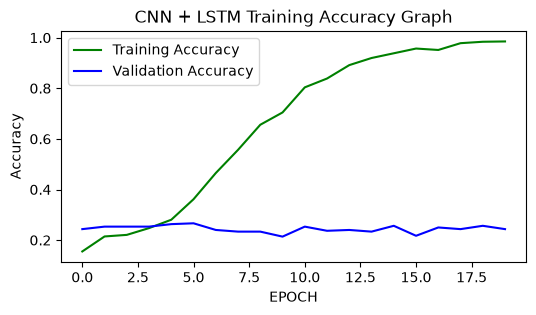

In [14]:
#visualizing model training and validation accuracy
f = open('model/cnn_history.pckl', 'rb')
train_values = pickle.load(f)
f.close()
plt.figure(figsize=(6, 3))
train_accuracy = train_values['accuracy']
val_accuracy = train_values['val_accuracy']
plt.xlabel('EPOCH')
plt.ylabel('Accuracy')
plt.plot(train_accuracy, color = 'green')
plt.plot(val_accuracy, color = 'blue')
plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='upper left')
plt.title('CNN + LSTM Training Accuracy Graph')
plt.show()

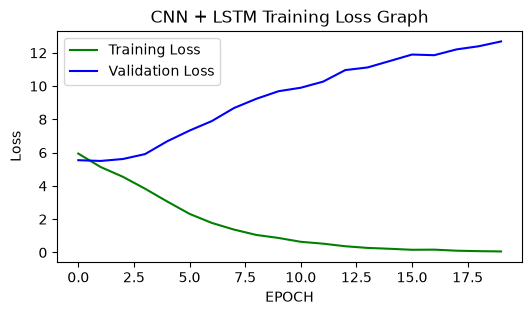

In [15]:
#visualizing model training and validation loss
plt.figure(figsize=(6, 3))
train_loss = train_values['loss']
val_loss = train_values['val_loss']
plt.xlabel('EPOCH')
plt.ylabel('Loss')
plt.plot(train_loss, color = 'green')
plt.plot(val_loss, color = 'blue')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper left')
plt.title('CNN + LSTM Training Loss Graph')
plt.show()

In [16]:
#function to get word by giving tokenizer id
def word_for_id(integer, tokenizr):
    for word, index in tokenizr.word_index.items():
        if index == integer:
            return word
    return None

In [17]:
#function to predict caption from given video features
def predictCaption(model, tokenizer, features, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        yhat = model.predict([features,sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = word_for_id(yhat, tokenizer)
        if word is None:
            break
        in_text += ' ' + word
        # stop if we predict the end of the sequence
        if word == 'endseq':
            break
    in_text = in_text.replace('startseq', "")
    in_text = in_text.replace('endseq', "")
    return in_text

In [18]:
#function to play video and display caption and sentiment
def playVideo(filename, caption, emotion):
    cap = cv2.VideoCapture(filename)
    while True:
        ret, frame = cap.read()
        if ret == True:
            frame = cv2.resize(frame, (800, 400))
            cv2.putText(frame, caption, (10, 25), cv2.FONT_HERSHEY_SIMPLEX,0.7, (255, 0, 0), 2)
            cv2.putText(frame, "Emotion "+emotion, (10, 55), cv2.FONT_HERSHEY_SIMPLEX,0.7, (255, 0, 0), 2)
            cv2.imshow('Output Video', frame)
            if cv2.waitKey(5) & 0xFF == ord('q'):
                break
        else:
            break
    cap.release()
    cv2.destroyAllWindows()

In [19]:
def getEmotion(text):
    global analyzer
    scores = analyzer.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return "Positive"
    elif scores['compound'] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [20]:
#this function read features from given video and predict caption
def readTestVideo(video_test):
    image_features = video_to_frames(video_test)
    photo = []
    photo.append(image_features)
    photo = np.asarray(photo)
    photo = scaler.transform(photo)
    caption = predictCaption(cnn_lstm_model, tokenizer, photo, max_length)
    emotion = getEmotion(caption)
    print("Caption = "+caption)
    print("Emotion = "+emotion)
    playVideo(video_test, caption, emotion)

In [23]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/1.avi")

Caption =  moški moški začimbe po korenju 
Emotion = Negative


In [24]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/2.avi")

Caption =  ženska nožem nareže kumaro 
Emotion = Neutral


In [25]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/3.avi")

Caption =  ženska olupi bučko 
Emotion = Neutral


In [26]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/4.avi")

Caption =  ženska nožem nareže kumaro 
Emotion = Neutral


In [27]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/5.avi")

Caption =  ženska nožem nareže kumaro 
Emotion = Neutral


In [28]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/6.avi")

Caption =  ženska nožem nareže brokoli 
Emotion = Neutral


In [29]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/7.avi")

Caption =  ženska kuhanemu rižu primeša več sestavin 
Emotion = Neutral


In [30]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/8.avi")

Caption =  moški rokami rokami po video ponvi 
Emotion = Negative


In [31]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/9.avi")

Caption =  ženska popraži sestavine loncu 
Emotion = Neutral


In [32]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/10.avi")

Caption =  ženska ženska paradižnik na vrtu 
Emotion = Neutral


In [33]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/11.avi")

Caption =  punca nožem naseklja čebulo 
Emotion = Neutral


In [34]:
#call this function with video file path to detect caption and emotion
readTestVideo("testVideos/12.avi")

Caption =  punca nožem naseklja čebulo 
Emotion = Neutral
